*  cv2 → OpenCV library (used for image processing)
*   numpy → used for arrays (images are stored as arrays)
*   matplotlib.pyplot → used to display images (like graphs)


In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

*   This module allows us to upload files from our computer
*  Colab stores file in a variable called uploaded



In [2]:
from google.colab import files
uploaded = files.upload()

Saving images.jpg to images.jpg


*   uploaded.keys()
uploaded is a dictionary (after file upload)
*   .keys() returns file names
*   list(uploaded.keys())
Converts keys into a list
*   [0] Gets the first file name
*   cv2.imread(...)
Reads the image from file name
*   List item

In [3]:
img = cv2.imread(list(uploaded.keys())[0])

*   cv2.cvtColor()
Function used to change color format
*   img
Input image (currently in BGR)
*   cv2.COLOR_BGR2RGB
Converts:
Blue → Red
Green → Green
Red → Blue

In [4]:
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

*   Converts 3-channel image → 1-channel
*   grayscale image (values 0–255)

In [5]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

*   0 → ignored because of OTSU
*   255 → max value
*   THRESH_BINARY_INV → invert colors
*   OTSU → automatically finds best threshold
*   Needed to separate object vs background
cv2.threshold(gray, thresh_value, max_val, type)

In [7]:
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

*   Removes small white noise
*   np.ones((3,3) creates a 3×3 matrix of ones
*   np.uint8 → data type (unsigned 8-bit integer)





In [8]:
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

*   Find sure bg



In [9]:
sure_bg = cv2.dilate(opening, kernel, iterations=3)

Calculates distance from nearest zero pixel

In [10]:
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

Keeps only strong center pixels
FInd sure fg

In [11]:
ret, sure_fg = cv2.threshold(dist_transform, 0.4 * dist_transform.max(), 255, 0)

*   Converts foreground to integer
*   Subtracts foreground from background



In [12]:
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

Labels each object with unique number
*   Background shifted to 1
*   Unknown set to 0



In [13]:
ret, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

*   Applies watershed segmentation

In [14]:
markers = cv2.watershed(img, markers)

*   Pixels with -1 = boundary
*   Color them red

In [15]:
img[markers == -1] = [0, 255, 0]

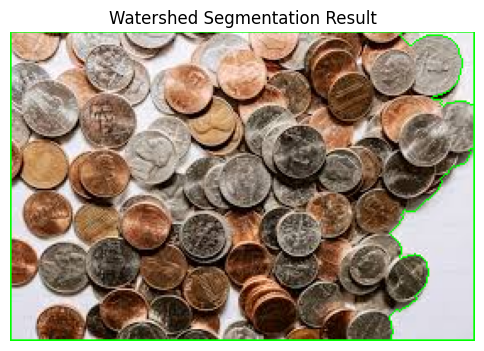

In [16]:
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Watershed Segmentation Result")
plt.axis('off')
plt.show()